In [280]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

from sklearn.preprocessing import StandardScaler,Normalizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,LogisticRegression,Lasso,Ridge,ElasticNet
from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor,plot_tree
from sklearn.neighbors import KNeighborsClassifier,KNeighborsRegressor
from mlxtend.plotting import plot_decision_regions
from sklearn.ensemble import AdaBoostClassifier,AdaBoostRegressor,GradientBoostingClassifier,GradientBoostingRegressor,BaggingClassifier,BaggingRegressor
from sklearn.metrics import root_mean_squared_error,mean_squared_error,mean_absolute_error,r2_score,recall_score,accuracy_score,confusion_matrix,classification_report

import xgboost as xgb

import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense
from tensorflow.keras.layers import Dropout

In [281]:
df =pd.read_csv("/Users/prathamsharma/Desktop/ELECTRICL SOP ZAFAR SIR/air_quality_health_impact_data.csv")

In [282]:
df.head()

,RecordID,AQI,PM10,PM2_5,NO2,SO2,O3,Temperature,Humidity,WindSpeed,RespiratoryCases,CardiovascularCases,HospitalAdmissions,HealthImpactScore,HealthImpactClass
0,1,187.270059,295.853039,13.038560,6.639263,66.161150,54.624280,5.150335,84.424344,6.137755,7,5,1,97.244041,0.0
1,2,475.357153,246.254703,9.984497,16.318326,90.499523,169.621728,1.543378,46.851415,4.521422,10,2,0,100.000000,0.0
2,3,365.996971,84.443191,23.111340,96.317811,17.875850,9.006794,1.169483,17.806977,11.157384,13,3,0,100.000000,0.0
3,4,299.329242,21.020609,14.273403,81.234403,48.323616,93.161033,21.925276,99.473373,15.302500,8,8,1,100.000000,0.0
4,5,78.009320,16.987667,152.111623,121.235461,90.866167,241.795138,9.217517,24.906837,14.534733,9,0,1,95.182643,0.0


In [283]:
x=df[[ "AQI" , "Temperature" , "Humidity" ]]
y = df["HealthImpactScore"]

print(x.shape , y.shape)

(5811, 3) (5811,)


In [284]:
x_train , x_test , y_train , y_test = train_test_split( x , y , test_size= 0.2 , random_state= 42)

In [285]:
print(x_train)

             AQI  Temperature   Humidity
2495  246.162740     6.483895  69.482701
2451  483.208693    -3.373430  97.806845
5206  400.920084    37.153150  40.961679
3666  419.590197    -6.102083  68.443069
3362  346.179461    33.022515  23.533900
...          ...          ...        ...
3772  171.978843     7.727584  41.333441
5191  350.404209    -3.943574  22.951993
5226  291.653624     0.969888  57.142306
5390   69.725118    -0.635148  38.152092
860   387.763808    -1.339353  54.877938

[4648 rows x 3 columns]


In [286]:
std = StandardScaler()
x_train_sclaed = std.fit_transform(x_train)
x_test_scaled = std.transform(x_test)

In [287]:
x_train_sclaed

array([[-0.02077126, -0.58424852,  0.56807284],
       [ 1.62281729, -1.26270132,  1.65919245],
       [ 1.05225865,  1.52663269, -0.53063105],
       ...,
       [ 0.29464562, -0.96376254,  0.09268875],
       [-1.24412416, -1.0742328 , -0.63886361],
       [ 0.96103792, -1.1227013 ,  0.0054594 ]])

In [288]:
x_test_scaled

array([[-0.87140374, -1.18008949,  0.79497966],
       [ 0.91282147, -0.08063888, -1.01198219],
       [ 1.64007407, -0.40359305,  1.47905015],
       ...,
       [ 1.12907453, -1.60256772,  1.11402345],
       [ 0.14445676,  0.04709353, -1.29723051],
       [ 1.67426547,  1.6910477 , -0.9433881 ]])

In [289]:
model = Sequential()

model.add(Dense( 64 , activation="relu" , input_dim = 3))

model.add(Dense( 64 , activation= "relu"))

model.add(Dense( 32 , activation= "relu"))

model.add(Dense( 8 , activation="relu"))

model.add(Dense(1))

from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=0.001)

model.compile(loss = "mse" , metrics=["mae"] ,optimizer="adam")

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [290]:
model.summary()

Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_99 (Dense)                │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_100 (Dense)               │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_101 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_102 (Dense)               │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_103 (Dense)               │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,769 (26.44 KB)

 Trainable params: 6,769 (26.44 KB)

 Non-trainable params: 0 (0.00 B)

In [291]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history =model.fit(
    x_train_sclaed, y_train,
    epochs=100,
    batch_size=20,
    validation_split=0.1,
    callbacks=[early_stop]
)

Epoch 1/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 853us/step - loss: 6729.5278 - mae: 75.8913 - val_loss: 418.0744 - val_mae: 16.4159
Epoch 2/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 584us/step - loss: 344.4121 - mae: 14.8064 - val_loss: 241.0950 - val_mae: 12.4324
Epoch 3/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 563us/step - loss: 211.8856 - mae: 11.4013 - val_loss: 152.7771 - val_mae: 9.4304
Epoch 4/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 538us/step - loss: 143.1366 - mae: 8.9961 - val_loss: 122.5282 - val_mae: 8.5957
Epoch 5/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 534us/step - loss: 114.1198 - mae: 7.6666 - val_loss: 96.5698 - val_mae: 6.9541
Epoch 6/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 534us/step - loss: 95.0742 - mae: 6.4738 - val_loss: 89.3158 - val_mae: 6.5063
Epoch 7/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 549us/step - loss: 78.9185 - mae: 5.6176 - val_loss: 76.5443 - val_mae: 5.4849
Epoch 8/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 559us/step - loss: 77.1505 - mae: 5.1177 - val_loss: 75.6947 - val_mae: 5.0714
E

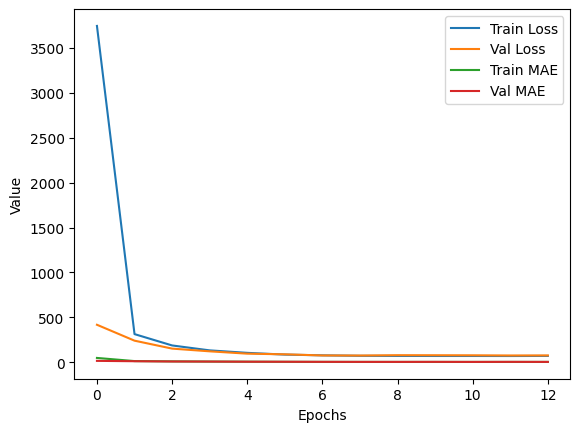

In [292]:
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.plot(history.history["mae"], label="Train MAE")
plt.plot(history.history["val_mae"], label="Val MAE")

plt.xlabel("Epochs")
plt.ylabel("Value")
plt.legend()
plt.show()

In [293]:
y_pred = model.predict(x_test_scaled)

print(y_pred)

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 999us/step
[[ 91.0333  ]
 [ 99.096   ]
 [101.21702 ]
 ...
 [102.00414 ]
 [ 99.160645]
 [102.942924]]


In [294]:
rmse = root_mean_squared_error(y_test , y_pred)
print("RMSE:",rmse)

RMSE: 8.590278209845556


PREDICTION MODEL

In [295]:
df

,RecordID,AQI,PM10,PM2_5,NO2,SO2,O3,Temperature,Humidity,WindSpeed,RespiratoryCases,CardiovascularCases,HospitalAdmissions,HealthImpactScore,HealthImpactClass
0,1,187.270059,295.853039,13.038560,6.639263,66.161150,54.624280,5.150335,84.424344,6.137755,7,5,1,97.244041,0.0
1,2,475.357153,246.254703,9.984497,16.318326,90.499523,169.621728,1.543378,46.851415,4.521422,10,2,0,100.000000,0.0
2,3,365.996971,84.443191,23.111340,96.317811,17.875850,9.006794,1.169483,17.806977,11.157384,13,3,0,100.000000,0.0
3,4,299.329242,21.020609,14.273403,81.234403,48.323616,93.161033,21.925276,99.473373,15.302500,8,8,1,100.000000,0.0
4,5,78.009320,16.987667,152.111623,121.235461,90.866167,241.795138,9.217517,24.906837,14.534733,9,0,1,95.182643,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5806,5807,171.112762,11.246387,197.984628,158.643107,17.743678,280.370909,37.359323,61.707640,4.097129,14,5,2,100.000000,4.0
5807,5808,490.691667,275.340762,55.774170,132.336871,29.334724,108.043492,34.532542,21.528555,6.682549,8,6,2,100.000000,3.0
5808,5809,314.841798,41.892699,184.708551,82.105823,68.334578,105.568503,22.975564,92.725625,2.889698,12,2,3,100.000000,1.0
5809,5810,208.080473,165.533785,199.177255,100.796385,87.586488,166.469537,36.090620,25.836286,10.722393,6,2,3,100.000000,4.0


In [296]:
x_input1 = [[ 187.270059 , 5.150335 , 84.424344 ]]


x_input1_scaled = std.transform(x_input1)

x_input1_resape = x_input1_scaled.reshape(1,-1)

y_pred_case1 = model.predict(x_input1_resape)
y_pred_case1

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[98.61265]], dtype=float32)

In [297]:
x_input2 = [[ 171.112762 , 37.359323 , 61.707640 ]]


x_input2_scaled = std.transform(x_input2)

x_input2_resape = x_input2_scaled.reshape(1,-1)

y_pred_case2 = model.predict(x_input2_resape)
y_pred_case2

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[95.65082]], dtype=float32)